# Pricing Function, Polynomial Approximation of Prices, and Battery Optimization
## version 1.1.2

Creating a simple function that determines price according to merit order data.

## Pricing Function Construction

In [1]:
# Let's load in the necessary packages
import pandas as pd
import datetime
import os
import timeit
import matplotlib.pyplot as plt
# from ortools.linear_solver import pywraplp
# from ortools.sat.python import cp_model
import gurobipy as gp
from gurobipy import GRB
import numpy as np

#### Function from Prof. Leach
Will use here the code that Professor Leach gave.
It's a function that gets the new price for a certain hour.

In [2]:
# Loading in the data first.
# Let's load in the data here, and for now, let's make it just for four hours.

file_name = os.fsdecode("marco_data_day.csv")
workbook = pd.read_csv(file_name)
# workbook = workbook.query('hour<=18 and hour>=15') # Remove this to take out the filter for the day.

# Getting the columns we need.
merit_data = workbook.filter(items=["date", "he", "size","flexible","price","ail","datetime"]) # Gets the columns that we need
# I added "datetime" above so that it will be easier to filter out the merit data when looping through.

pd.set_option('display.max_rows',500)

# Temporary peek: These lines are all just for looking at the dataframe to track the code that loops
temp = merit_data.copy()
temp = temp.query('he == 15')
temp['merit'] = temp['size'].cumsum()
temp['surplus'] = temp['merit'] -2000 # temp['ail']
# temp

In [3]:
# Making everything we have above into a function:

def pricing(bids, ail): # Bids is self-explanatory, so set of bids needed.
    bids=bids.sort_values('price', ignore_index=True) # Need to add reset_index because of the entries that have 0 pricing.
    # bids=bids.assign(merit=bids['size'].cumsum())
    bids['merit'] = bids['size'].cumsum() # Old code is above
    # bids = bids.assign(surplus=bids['merit']-bids['ail'].max())
    bids['surplus'] = bids['merit'] - ail
    last_full=bids.query('surplus<=0')['surplus'].idxmax()
    # Made this change to get the actual energy needed left
    e_needed=-bids['surplus'][last_full] # Getting the last negative surplus value since that's the amound lacking
    while(e_needed>0):
        last_full += 1
        if(bids['size'][last_full]<e_needed): #dispatch it
            e_needed-=bids['size'][last_full]
        elif (bids['size'][last_full]>=e_needed) and (bids['flexible'][last_full]=="Y"): #dispatch part of it 
            e_needed-=e_needed
        # Made changes in the bids below to get the price accurately
        price=bids['price'][last_full-1]
        # Line below just shows a track of the outputs; unsilence it if you need to debug.
        # print(e_needed,last_full-1,price)
        
        return(price)


In [4]:
# Trying out our function

pricing(merit_data.query('he==15'),8000)

27.18

## Price vs. AIL Curve
Now using the same logic to see how price looks over all of the AIL

In [5]:
# We can use the same function above to create a price curve for all levels of AIL, just with a few changes.


def price_curve_ail(bids_hour,ail,pcurve_res):
    # Empty dataframe to collect the information
    price_curve_data = pd.DataFrame()
    # Variable that will be used to adjust the ail during the loop. Set to 0 to get original price with no change.
    c = 1 # Has to start with one because of the way the pricing function is set up. Setting it to 0 causes an error. Will look further into this.

    # Empty lists to collect the information first that will then be put into the empty dataframe
    prices=[]
    powers=[]
    
    # The loop
    for i in range(abs(round(ail/pcurve_res))):
        prices.append(pricing(bids_hour,c))
        powers.append(c)
        c += pcurve_res
    
    # Putting together the dataframe of prices and power levels
    price_curve_data['price']=prices
    price_curve_data['AIL']=powers
    price_curve_data['revenue']=price_curve_data['price']*price_curve_data['AIL']

    return(price_curve_data)


In [6]:
# Now let's test this out

pcurve_ail = price_curve_ail(merit_data.query('he==15'),9500,1)

In [7]:
# Slapping on the date and time for that specific dataset for better clarity
pcurve_ail['datetime'] = merit_data[merit_data['he']==15].iloc[0]['datetime']
# Rearranging the columns
pcurve_ail = pcurve_ail[['datetime','price','AIL','revenue']]
pcurve_ail

,datetime,price,AIL,revenue
0,2018-08-05 15:00:00,0.00,1,0.00
1,2018-08-05 15:00:00,0.00,2,0.00
2,2018-08-05 15:00:00,0.00,3,0.00
3,2018-08-05 15:00:00,0.00,4,0.00
4,2018-08-05 15:00:00,0.00,5,0.00
...,...,...,...,...
9495,2018-08-05 15:00:00,109.89,9496,1043515.44
9496,2018-08-05 15:00:00,109.89,9497,1043625.33
9497,2018-08-05 15:00:00,109.89,9498,1043735.22
9498,2018-08-05 15:00:00,110.00,9499,1044890.00


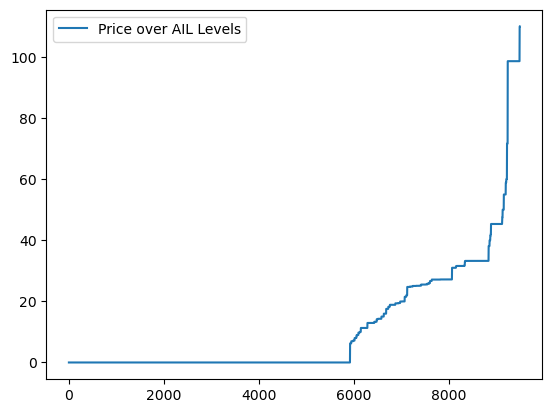

In [8]:
# Now let's graph the price curve over the whole AIL

pltx = pcurve_ail['AIL']
plty = pcurve_ail['price']

# Plotting the lines
plt.plot(pltx, plty, label = "Price over AIL Levels")

plt.legend()
plt.show()

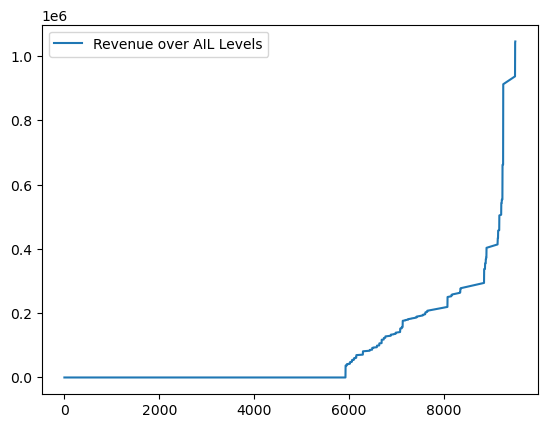

In [9]:
# Now let's graph the revenue curve over the whole AIL

pltx = pcurve_ail['AIL']
plty = pcurve_ail['revenue']

# Plotting the lines
plt.plot(pltx, plty, label = "Revenue over AIL Levels")

plt.legend()
plt.show()

## Numpy Polyfit
Using numpy.polyfit here to create approximations.

In [10]:
# From the tutorial, let's try out numpy.polyfit and create a polynomial for the set of points we have for the prices

# np.polyfit is the command that fits the datapoints into a polynomial. 
# "deg" is the degree of the fitting polynomial. 
# pcurve_ail['AIL'] are our x-values
# the prices are our y-values
coeff = np.polyfit(pcurve_ail['AIL'],pcurve_ail['price'],deg=7)

# np.poly1d stores the function
function = np.poly1d(coeff)

# Typing it out lets us look at the polynomial that was created.
function


poly1d([ 5.71130487e-24, -1.72636411e-19,  2.03575477e-15, -1.18269540e-11,
        3.53333274e-08, -5.13570021e-05,  3.02181657e-02, -4.21979405e+00])

In [11]:
# Now we need to try and graph it.

# We store the y-values from our fitted polynomial function
price_approx = function(pcurve_ail['AIL'])

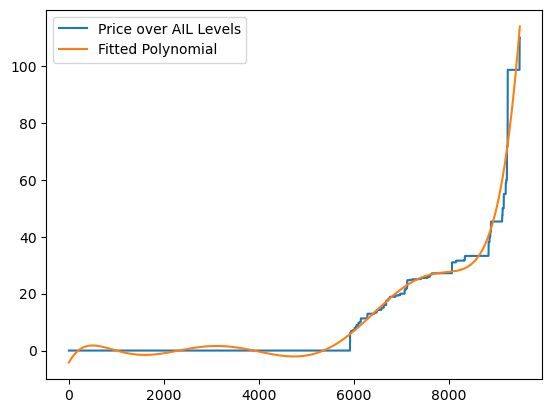

In [12]:
# Now let's graph the approximate prices against the actual prices in our data.

pltx = pcurve_ail['AIL']
plty = pcurve_ail['price']
plty2 = price_approx

# Plotting the lines
plt.plot(pltx, plty, label = "Price over AIL Levels")
plt.plot(pltx,plty2,label = 'Fitted Polynomial')

plt.legend()
plt.show()

For the codes below, I'm trying to see if we can store the functions in something like a list (and hopefully a dataframe cell) so that it would be possible to call upon it and use it. This is because in the future, we would need to make a polynomial approximation for each hour of our dataset. It also makes it a lot easier to call a function from a set of functions.

In [13]:
function_list = [] # Create an empty list
function_list.append(function) # Putting our function in the list
function_list 

[poly1d([ 5.71130487e-24, -1.72636411e-19,  2.03575477e-15, -1.18269540e-11,
         3.53333274e-08, -5.13570021e-05,  3.02181657e-02, -4.21979405e+00])]

In [14]:
# Here I print out the specific element of the list (our function) to see if it still shows the same thing as printing it out using numpy.poly1d
print(function_list[0])

           7             6             5             4             3
5.711e-24 x - 1.726e-19 x + 2.036e-15 x - 1.183e-11 x + 3.533e-08 x
              2
 - 5.136e-05 x + 0.03022 x - 4.22


In [15]:
# Testing out using the function from calling it as an element of a list.
function_list[0](pcurve_ail['AIL'])

array([ -4.1896272 ,  -4.15956286,  -4.12960081, ..., 113.47416182,
       113.6794035 , 113.88503246])

It seems to work, so let's hope it will work when we put all of that into a dataframe. Other option is to keep it in a list that will have the same index as the merit order data above.

## Approximating a Polynomial for all hours of the market
Let's get everything we've done above and try to use it for all the data and the hours that we have. What I'm going to do here is make some code that will loop through all the hours and create a polynomial approximation of each price curve for each hour.

In [16]:
# I'm getting the distinct hours of our dataset that our algorithm will loop through.
time_index = merit_data['datetime'].unique()
time_index

array(['2018-08-05 01:00:00', '2018-08-05 02:00:00',
       '2018-08-05 03:00:00', '2018-08-05 04:00:00',
       '2018-08-05 05:00:00', '2018-08-05 06:00:00',
       '2018-08-05 07:00:00', '2018-08-05 08:00:00',
       '2018-08-05 09:00:00', '2018-08-05 10:00:00',
       '2018-08-05 11:00:00', '2018-08-05 12:00:00',
       '2018-08-05 13:00:00', '2018-08-05 14:00:00',
       '2018-08-05 15:00:00', '2018-08-05 16:00:00',
       '2018-08-05 17:00:00', '2018-08-05 18:00:00',
       '2018-08-05 19:00:00', '2018-08-05 20:00:00',
       '2018-08-05 21:00:00', '2018-08-05 22:00:00',
       '2018-08-05 23:00:00', '2018-08-06 00:00:00'], dtype=object)

In [17]:
# Let's create a loop that will make a price curve for each hour, and store it all in one data set.

ail_pcurve_total = pd.DataFrame()

# Let's loop through and create a dataframe for each hour that stores the price curve, then connects it all together.
for i in time_index:

    # Filters out the specific hour
    pcurve_ail = price_curve_ail(merit_data[merit_data['datetime']==i],10000,1)

    # The next codes put a datetime into the temporary dataset, so that our final total price curve dataset has a datetime column
    # We need that for filtering for the polynomial approximation.
    pcurve_ail['datetime'] = merit_data[merit_data['datetime']==i].iloc[0]['datetime'] # Gets the datetime for that hour
    pcurve_ail = pcurve_ail[['datetime','price','AIL','revenue']] # Rearranges the columns

    # And now we put it into our main dataframe by using pd.concat()
    ail_pcurve_total = pd.concat([ail_pcurve_total,pcurve_ail], ignore_index=True)

ail_pcurve_total


,datetime,price,AIL,revenue
0,2018-08-05 01:00:00,0.00,1,0.00
1,2018-08-05 01:00:00,0.00,2,0.00
2,2018-08-05 01:00:00,0.00,3,0.00
3,2018-08-05 01:00:00,0.00,4,0.00
4,2018-08-05 01:00:00,0.00,5,0.00
...,...,...,...,...
239995,2018-08-06 00:00:00,968.75,9996,9683625.00
239996,2018-08-06 00:00:00,968.75,9997,9684593.75
239997,2018-08-06 00:00:00,968.75,9998,9685562.50
239998,2018-08-06 00:00:00,968.75,9999,9686531.25


In [18]:
# Now let's create a loop that makes a polynomial approximation for each price curve and stores each in a table.

# Making an empty dataframe that will collect all the polynomials that will be approximated.
function_table = pd.DataFrame()

# Now making a column for the different hours of our data:
function_table['datetime'] = merit_data['datetime'].unique()

# Let's create an empty list that stores the function for each hour
function_list = []

# Creating an empty list that stores the coefficients of each function for each hour
coeff_list = []

for i in time_index:
    
    # To make it cleaner, let's store the AIL levels and prices in variables before fitting them into a polynomial
    x = ail_pcurve_total[ail_pcurve_total['datetime']==i]['AIL']
    y = ail_pcurve_total[ail_pcurve_total['datetime']==i]['price']

    # And now let's create the coefficients of our polynomial using numpy.polyfit()
    # "deg" chooses the degree of the polynomial. We can change this later
    coeff = np.polyfit(x,y,deg=7)
    # And then we store it in the coeff_list to save for each hour
    coeff_list.append(coeff)

    # Using numpy.poly1d() we store the function
    function = np.poly1d(coeff)

    # And then we store it in the function_list to save each function
    function_list.append(function)

# Putting the list that was made into our table
function_table['poly_funct'] = function_list
function_table['funct_coeff'] = coeff_list

# Let's take a look at our table
function_table


,datetime,poly_funct,funct_coeff
0,2018-08-05 01:00:00,"[4.3700985449242926e-23, -1.3953906234305262e-...","[4.3700985449242926e-23, -1.3953906234305262e-..."
1,2018-08-05 02:00:00,"[3.983348458703334e-23, -1.2521079030384006e-1...","[3.983348458703334e-23, -1.2521079030384006e-1..."
2,2018-08-05 03:00:00,"[3.876741824117564e-23, -1.214557832258675e-18...","[3.876741824117564e-23, -1.214557832258675e-18..."
3,2018-08-05 04:00:00,"[3.944662357895586e-23, -1.2388844755513746e-1...","[3.944662357895586e-23, -1.2388844755513746e-1..."
4,2018-08-05 05:00:00,"[3.0957725325525725e-23, -9.458690714352596e-1...","[3.0957725325525725e-23, -9.458690714352596e-1..."
5,2018-08-05 06:00:00,"[3.35561538672884e-23, -1.0344083009982687e-18...","[3.35561538672884e-23, -1.0344083009982687e-18..."
6,2018-08-05 07:00:00,"[3.857978669355698e-23, -1.2086549814706459e-1...","[3.857978669355698e-23, -1.2086549814706459e-1..."
7,2018-08-05 08:00:00,"[4.1516964939373726e-23, -1.3232880059316462e-...","[4.1516964939373726e-23, -1.3232880059316462e-..."
8,2018-08-05 09:00:00,"[4.2207735630870654e-23, -1.3365985307032906e-...","[4.2207735630870654e-23, -1.3365985307032906e-..."
9,2018-08-05 10:00:00,"[4.191608713423051e-23, -1.3225875098608098e-1...","[4.191608713423051e-23, -1.3225875098608098e-1..."


In [19]:
# Now let's check if we can call and use a function from the function_table dataframe directly
# We can put any theoretical value that's witihin the domain [1,10000], which we put in above.
function_table.iloc[2]['poly_funct'](8756)

# It seems to work! That's good news for now.


-1.7085805059795973

In [20]:
# Let's also look at how the function looks like if we call the coefficients:
function_table.iloc[2]['funct_coeff']

array([ 3.87674182e-23, -1.21455783e-18,  1.49613867e-14, -9.17866619e-11,
        2.92679424e-07, -4.58277081e-04,  2.92626284e-01, -4.45827576e+01])

In [21]:
# Checking to see if it works on a whole array of values
function_table.iloc[2]['poly_funct'](ail_pcurve_total[ail_pcurve_total['datetime']==time_index[2]]['AIL'])

array([ -44.29058929,  -43.99933579,  -43.70899534, ..., 1116.82132317,
       1119.30587987, 1121.79461517])

## Battery Optimization
Now it's time to build up the algorithm again that will hopefully optimize the battery.

In [22]:
#### BATTERY DATA ####

# Creating the parameters of the battery here, and if we want to make changes to our battery this is where we can adjust it.
batt_dict = {
    'max_charge_rate':100,
    'max_discharge_rate':100,
    'capacity':400,
    'charge_eff':0.05,
    'discharge_eff':0.05,
    'min_soc':0.05,
    'max_soc':0.95,
    'initial_soc':0.5
}

battDF = pd.DataFrame.from_dict(batt_dict, orient = 'index').transpose()
del batt_dict
battDF

,max_charge_rate,max_discharge_rate,capacity,charge_eff,discharge_eff,min_soc,max_soc,initial_soc
0,100.0,100.0,400.0,0.05,0.05,0.05,0.95,0.5


In [23]:
#### AIL DATA ####

# We need to create a dataframe that shows the AIL for each hour
# The reason is from there, our model should determine the battery's power and the price.
ail_data = pd.DataFrame()
ail_data['datetime'] = merit_data['datetime'].unique()
ail_data['ail'] = merit_data['ail'].unique()
ail_data.iloc[2]['ail']

7843.7153

In [24]:
## CREATING THE MODEL

# Here is a major change, and we will try to create another optimizing algorithm based solely on gurobi
# It will be different from the author's code, but we will use the same logic.

# First let's create the model
bm = gp.Model("qp")

inf = GRB.INFINITY

Set parameter Username
Academic license - for non-commercial use only - expires 2025-09-12


In [25]:
## Let's create the variables
# It's slightly different now because we're using Gurobi

# Create an index for the number of periods
tIndex = len(time_index)

# Now creating the variables of a simpler battery
vBattPower = [bm.addVar(lb = -inf, ub = inf, name = "") for _ in range(tIndex)]
# Battery Capacity Constraint. This needs to be changed soon.
vSOC = [bm.addVar(lb = 0, ub = 400, name = "") for _ in range(tIndex)]

# Creating a variable for the price and "new" AIL after the battery comes in
# Configuring the price to follow our polynomial price approximation will be done in the constraints.
vPrice = [bm.addVar(lb = -inf, ub = inf, name="") for _ in range(tIndex)]
# Adding an "AIL" variable that takes the value of the AIL after the battery has done its action for the hour
vAILnew = [bm.addVar(lb = -inf, ub = inf, name="") for _ in range(tIndex)]
vRevenue = [bm.addVar(lb = -inf, ub = inf, name="") for _ in range(tIndex)]



In [26]:
## CONSTRAINTS

for i in range(tIndex):

    #---------------------------------------------------------------------------------------------------------------------------
    #### Battery Constraints:

    # Power flow constraints
    bm.addConstr(vBattPower[i] >= -battDF.iloc[0]['max_discharge_rate'])
    bm.addConstr(vBattPower[i] <= battDF.iloc[0]['max_charge_rate'])

    # Law of Motion for the state of charge of the battery:
    if i == 0:
        bm.addConstr(vSOC[i] == 0 + vBattPower[i])
    else:
        bm.addConstr(vSOC[i] == vSOC[i-1] + vBattPower[i])

    #---------------------------------------------------------------------------------------------------------------------------

    # We need another simple constraint, that simply determines the AIL for the hour
    bm.addConstr(vAILnew[i]==ail_data.iloc[i]['ail']+vBattPower[i])

    # This is the "Price Constraint" that maps out our prices for each hour of the data
    # This method from Gurobi allows polynomial constraints, so we make one that determines the new price each hour
    bm.addGenConstrPoly(vAILnew[i], vPrice[i], function_table.iloc[i]['funct_coeff'])

    bm.addConstr(vRevenue[i] == vPrice[i]*vBattPower[i])

In [27]:
#---------------------------------------------------------------
# Objective Function Setup

# Add objective
# Changed the objective to sum up the battery energy times the price, instead of power in the grid.
obj = 0
# Old:
# obj += -sum([vBattPower[i] * marketDF["market_price_1"].iloc[i] * dt for i in range(tIndex)])
# obj += -sum([vBattPower[i] * price_map[(price_map['datetime']==marketDF['time'].iloc[i])&(price_map['batt_power']==vBattPower[i])].iloc[0]['new_price'] * dt for i in range(tIndex)])
obj += -sum([vRevenue[i] for i in range(tIndex)])

# Setting the objective
bm.setObjective(obj)
#---------------------------------------------------------------

In [28]:
# Command that tells gurobi to optimize the model.

bm.optimize()

Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11.0 (22631.2))

CPU model: AMD Ryzen 5 8645HS w/ Radeon 760M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 96 rows, 120 columns and 167 nonzeros
Model fingerprint: 0x073ea652
Model has 24 quadratic constraints
Model has 24 general constraints
Variable types: 120 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [4e+02, 4e+02]
  RHS range        [1e+02, 9e+03]
Presolve added 0 rows and 15 columns
Presolve removed 9 rows and 0 columns
Presolve time: 0.00s
Presolved: 183 rows, 135 columns, 533 nonzeros
Presolved model has 24 bilinear constraint(s)

Solving non-convex MIQCP

Variable types: 125 continuous, 10 integer (10 binary)
Found heuristic solution: objectiv

In [32]:
vBattPower

[<gurobi.Var C0 (value 0.0)>,
 <gurobi.Var C1 (value 13.800500155586494)>,
 <gurobi.Var C2 (value 58.186263891948514)>,
 <gurobi.Var C3 (value 28.01323595246656)>,
 <gurobi.Var C4 (value 100.0)>,
 <gurobi.Var C5 (value 100.0)>,
 <gurobi.Var C6 (value 100.0)>,
 <gurobi.Var C7 (value 0.0)>,
 <gurobi.Var C8 (value 0.0)>,
 <gurobi.Var C9 (value 0.0)>,
 <gurobi.Var C10 (value -7.031250000013626)>,
 <gurobi.Var C11 (value 7.031250000013642)>,
 <gurobi.Var C12 (value -22.65625000009277)>,
 <gurobi.Var C13 (value 22.65625000009277)>,
 <gurobi.Var C14 (value -19.921875000003524)>,
 <gurobi.Var C15 (value -48.82812499999845)>,
 <gurobi.Var C16 (value -85.15625000000631)>,
 <gurobi.Var C17 (value -100.0)>,
 <gurobi.Var C18 (value -100.0)>,
 <gurobi.Var C19 (value -46.093749999991715)>,
 <gurobi.Var C20 (value 100.0)>,
 <gurobi.Var C21 (value -33.593750000002515)>,
 <gurobi.Var C22 (value -66.40624999999748)>,
 <gurobi.Var C23 (value 0.0)>]

In [40]:
# Let's collect the values of the battery's decisions

bpower = [] # Empty list to get the values

for i in range(len(vBattPower)):
    bpower.append(vBattPower[i].X) # To get only the value of the variable, use the .X attribute

battery_results = pd.DataFrame() # Empty Dataframe to get values

# Making the dataframe presentable and in a good format:
battery_results['datetime'] = merit_data['datetime'].unique()
battery_results['vBattPower'] = bpower
del bpower # Deleting to save memory

# Looking at the results
battery_results

# NOTE: Negative is discharging/selling, while positive is charging.

,datetime,vBattPower
0,2018-08-05 01:00:00,0.000000
1,2018-08-05 02:00:00,13.800500
2,2018-08-05 03:00:00,58.186264
3,2018-08-05 04:00:00,28.013236
4,2018-08-05 05:00:00,100.000000
5,2018-08-05 06:00:00,100.000000
6,2018-08-05 07:00:00,100.000000
7,2018-08-05 08:00:00,0.000000
8,2018-08-05 09:00:00,0.000000
9,2018-08-05 10:00:00,0.000000


In [59]:
# Now let's get the prices and compare it
# Let's list the actual, before the battery comes in, after it comes in, and also the polynomial approximate

# Creating the empty lists:
original_price = []
new_price = []
poly_price = []

ail_list = merit_data['ail'].unique()

# Looping to create prices:
for t in range(len(time_index)):
    # Collecting the original price based on our main pricing function
    original_price.append(pricing(merit_data[merit_data['datetime']==time_index[t]],ail_list[t]))
    # Getting the new price after the battery comes in
    new_price.append(pricing(merit_data[merit_data['datetime']==time_index[t]],ail_list[t]+battery_results.iloc[t]['vBattPower']))
    # Getting the polynomial approximated price which was used in the algorithm
    poly_price.append(function_table.iloc[t]['poly_funct'](ail_list[t]+battery_results.iloc[t]['vBattPower']))


battery_results['original_price'] = original_price
battery_results['new_price'] = new_price
battery_results['poly_price'] = poly_price
battery_results


,datetime,vBattPower,original_price,new_price,poly_price
0,2018-08-05 01:00:00,0.000000,31.68,31.68,39.055366
1,2018-08-05 02:00:00,13.800500,31.68,31.68,37.377620
2,2018-08-05 03:00:00,58.186264,31.68,31.68,33.682534
3,2018-08-05 04:00:00,28.013236,31.68,31.68,36.018946
4,2018-08-05 05:00:00,100.000000,31.68,31.68,25.778629
5,2018-08-05 06:00:00,100.000000,31.00,31.68,32.563245
6,2018-08-05 07:00:00,100.000000,27.17,27.17,52.875350
7,2018-08-05 08:00:00,0.000000,27.18,27.18,46.097522
8,2018-08-05 09:00:00,0.000000,31.00,31.00,28.474412
9,2018-08-05 10:00:00,0.000000,33.25,33.25,-3.690678


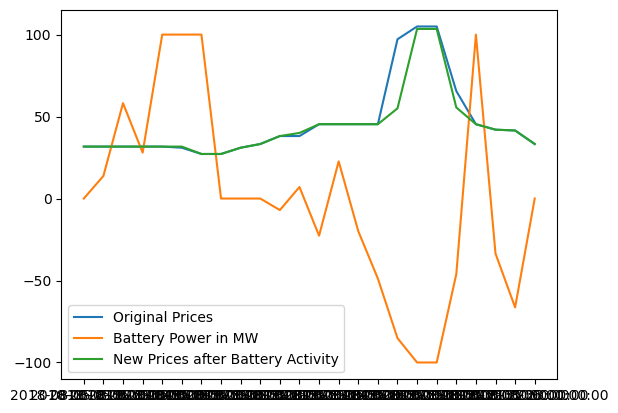

In [61]:
# I want to see all these in a graph

# Now let's graph the approximate prices against the actual prices in our data.

pltx = battery_results['datetime']
plty = battery_results['original_price']
plty2 = battery_results['vBattPower']
plty3 = battery_results['new_price']

# Plotting the lines
plt.plot(pltx, plty, label = "Original Prices")
plt.plot(pltx,plty2,label = 'Battery Power in MW')
plt.plot(pltx,plty3,label = 'New Prices after Battery Activity')

plt.legend()
plt.show()